In [1]:
import numpy as np
import netket as nk
import matplotlib.pyplot as plt
import json

In [2]:
N = 12
data_file = "../data/results_N12_vs_T.txt"

with open(data_file, "r") as f:
    data = json.load(f)

T_array = np.array(data["T"])
energy_results = data["energy"]
entropy_results = data["entropy"]
free_energy_results = data["free_energy"]

In [3]:
from netket.operator.spin import sigmax, sigmaz

hi_system = nk.hilbert.Spin(s=1/2, N=N)

Gamma = -1.5  
V = -1
H_system=0
for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

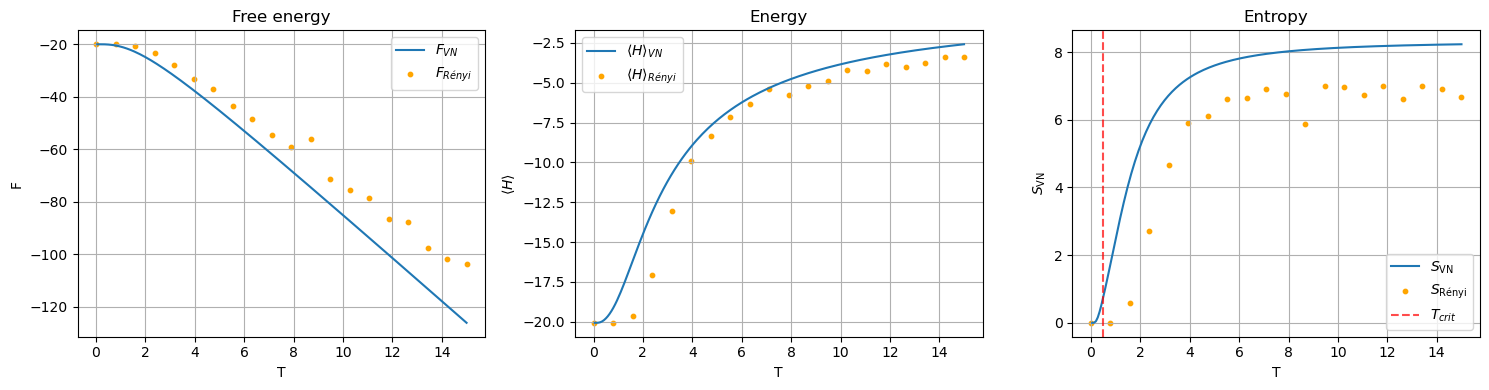

In [4]:
# --- Convertir H a matriz densa  ---
H_matrix = H_system.to_dense()

# --- Diagonalización (solo una vez) ---
eigvals, eigvecs = np.linalg.eigh(H_matrix)
t_c =(eigvals[1]-eigvals[0])/2

def canonical_ensemble(eigvals, eigvecs, T):
    """Calcula F, <H>, S_VN exactos para temperatura T."""
    # Poblaciones de Boltzmann
    log_pops = -eigvals / T
    log_pops -= np.max(log_pops)  
    pops = np.exp(log_pops)
    Z = pops.sum()
    pops /= Z
    
    # Energía
    energy = np.sum(pops * eigvals)
    
    # Entropía de Von Neumann (en base diagonal de H, ρ ya es diagonal)
    mask = pops > 1e-15
    S_VN = -np.sum(pops[mask] * np.log(pops[mask]))
    
    # Energía libre
    F = energy - T * S_VN
    
    return F, energy, S_VN

# --- Barrido en temperatura ---
temperatures = np.linspace(0.05, 15, 200)  # evitar T=0

F_list, E_list, S_list = [], [], []
for T in temperatures:
    F, E, S = canonical_ensemble(eigvals, eigvecs, T)
    F_list.append(F)
    E_list.append(E)
    S_list.append(S)

F_arr = np.array(F_list)
E_arr = np.array(E_list)
S_arr = np.array(S_list)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(temperatures, F_arr, label=r'$F_{VN}$')
axes[0].scatter(T_array, free_energy_results, color="orange", label=r'$F_{Rényi}$', s=10)
axes[0].set_xlabel('T'); axes[0].set_ylabel('F')
axes[0].set_title('Free energy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(temperatures, E_arr, label=r'$\langle H \rangle_{VN}$')
axes[1].scatter(T_array, energy_results, color="orange", label=r'$\langle H \rangle_{Rényi}$', s=10)
axes[1].set_xlabel('T'); axes[1].set_ylabel(r'$\langle H \rangle$')
axes[1].set_title('Energy')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(temperatures, S_arr, label=r'$S_\mathrm{VN}$')
axes[2].scatter(T_array, entropy_results, color="orange", label=r'$S_\mathrm{Rényi}$', s=10)
axes[2].set_xlabel('T'); axes[2].set_ylabel(r'$S_\mathrm{VN}$')
axes[2].axvline(x=t_c, color='red', linestyle='--', alpha=0.7, label=r"$T_{crit}$")
axes[2].set_title('Entropy')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()